# 01 · Data overview: RGB and RGB+NIR

This notebook introduces the imagery and pixel labels used in the two-channel-set comparison. The final training implementation is in [Notebook 08](08_train_public_unet_rgb_vs_rgb_nir.ipynb).

| Experiment | Input bands | Target |
|---|---|---|
| RGB | B4/B3/B2 | Water / non-water |
| RGB+NIR | B4/B3/B2/B8 | The same labels |

In [1]:
%matplotlib inline
from pathlib import Path
import csv
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display, Markdown

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BASE = ROOT / "data/sen1floods11/v1.1"
HAND = BASE / "data/flood_events/HandLabeled"
FIGURES = ROOT / "outputs/data_preview/rgb_nir"
FIGURES.mkdir(parents=True, exist_ok=True)
EXPERIMENTS = {"RGB (control)": ["B4", "B3", "B2"],
               "RGB+NIR (main)": ["B4", "B3", "B2", "B8"]}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white"})

def display_rgb(bands):
    # Display only; the model uses fixed scaling, not percentile stretching.
    rgb = np.moveaxis(bands, 0, -1)
    low, high = np.nanpercentile(rgb, [2, 98], axis=(0, 1))
    return np.nan_to_num(np.clip((rgb - low) / np.maximum(high - low, 1e-6), 0, 1))

def show_figure(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 1. Dataset and official splits

Sen1Floods11 provides 446 paired S2Hand optical images and LabelHand masks. Use the official train/validation/test/Bolivia split: **252/89/90/15**. The 13-band files already contain all four required bands.

Labels are **0 = non-water, 1 = water, -1 = ignored**. Water labels include permanent water bodies. Both experiments use the same images, labels and spatial grids.

**Local data: 446 optical images and 446 label masks.**

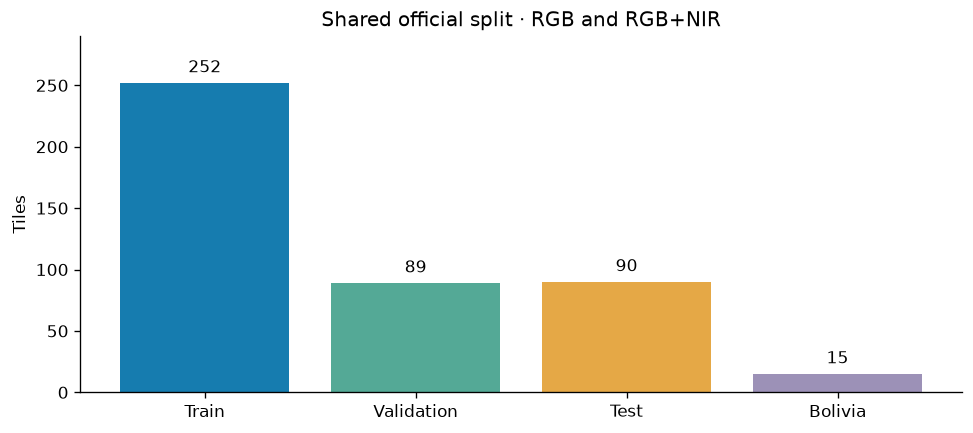

In [2]:
image_count = len(list((HAND / "S2Hand").glob("*.tif")))
label_count = len(list((HAND / "LabelHand").glob("*.tif")))
splits = {}
for name in ["train", "valid", "test", "bolivia"]:
    with (BASE / f"splits/flood_handlabeled/flood_{name}_data.csv").open(newline="") as f:
        splits[name] = list(csv.reader(f))
display(Markdown(f"**Local data: {image_count} optical images and {label_count} label masks.**"))
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
bars = ax.bar(["Train", "Validation", "Test", "Bolivia"],
              [len(rows) for rows in splits.values()],
              color=["#167caf", "#54a996", "#e5a846", "#9c91b7"])
ax.bar_label(bars, padding=4)
ax.set(title="Shared official split · RGB and RGB+NIR", ylabel="Tiles", ylim=(0, 290))
show_figure(fig, "01_shared_split")


## 2. Imagery and labels

`India_285297` is a fixed training example. Compare RGB, B8 near-infrared, the human label and a label overlay.

RGB uses a 2–98% display stretch; NIR is displayed over 0–0.6 reflectance. These settings affect visualization only. Labels use nearest-neighbor rendering, with grey for ignored pixels, beige for non-water and blue for water.

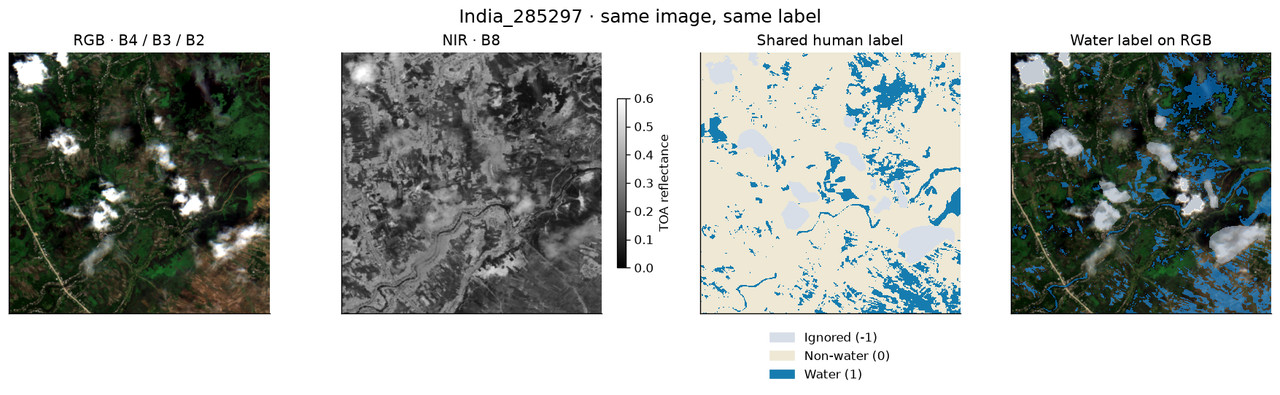

Source shape (R, G, B, NIR): (4, 512, 512)
Grid: EPSG:4326, pixel spacing 0.00008983 degrees


In [3]:
SAMPLE = "India_285297"
BANDS = EXPERIMENTS["RGB+NIR (main)"]
with rasterio.open(HAND / "S2Hand" / f"{SAMPLE}_S2Hand.tif") as src:
    indexes = [src.descriptions.index(band) + 1 for band in BANDS]
    optical = src.read(indexes, masked=True).astype("float32").filled(np.nan)
    grid_description = f"{src.crs}, pixel spacing {src.res[0]:.8f} degrees"
with rasterio.open(HAND / "LabelHand" / f"{SAMPLE}_LabelHand.tif") as src:
    label = src.read(1)
rgb = display_rgb(optical[:3])
nir = optical[3] / 10000.0
colors = ["#d7dee7", "#eee8d5", "#167caf"]
label_cmap = ListedColormap(colors)
label_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3)
overlay = np.zeros((*label.shape, 4))
overlay[label == 1] = [0.04, 0.57, 0.95, 0.58]
overlay[label == -1] = [0.65, 0.69, 0.74, 0.65]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.4), layout="constrained")
axes[0].imshow(rgb)
axes[0].set_title("RGB · B4 / B3 / B2")
im = axes[1].imshow(nir, cmap="gray", vmin=0, vmax=0.6)
axes[1].set_title("NIR · B8")
fig.colorbar(im, ax=axes[1], shrink=0.65, label="TOA reflectance")
axes[2].imshow(label, cmap=label_cmap, norm=label_norm, interpolation="nearest")
axes[2].set_title("Shared human label")
axes[2].legend(handles=[Patch(color=c, label=t) for c,t in zip(
    colors, ["Ignored (-1)", "Non-water (0)", "Water (1)"])],
    loc="upper center", bbox_to_anchor=(0.5, -0.03), frameon=False)
axes[3].imshow(rgb)
axes[3].imshow(overlay, interpolation="nearest")
axes[3].set_title("Water label on RGB")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{SAMPLE} · same image, same label", fontsize=15)
show_figure(fig, "02_rgb_nir_label")
print("Source shape (R, G, B, NIR):", optical.shape)
print("Grid:", grid_description)


B4, B3, B2 and B8 have a native Sentinel-2 resolution of 10 m. The distributed images use a common 512 × 512 geographic grid, so degree-based pixel spacing should not be interpreted as a uniform metric distance. Adding B8 requires no additional resampling.

Continue with [08 · Final U-Net experiment](08_train_public_unet_rgb_vs_rgb_nir.ipynb). Notebooks 02–07 preserve the earlier experiments and diagnostics; they are not prerequisites for running 08.